In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [12]:
lamba = 3
n = 1000
N = 1000

Вероятность успеха p = 0.003000
Количество успехов: 1000 значений
Среднее количество успехов: 2.963 (ожидаемое: 3.0)
Расстояния между успехами: 2008 значений
Среднее расстояние: 0.19878 (ожидаемое: 0.33333)


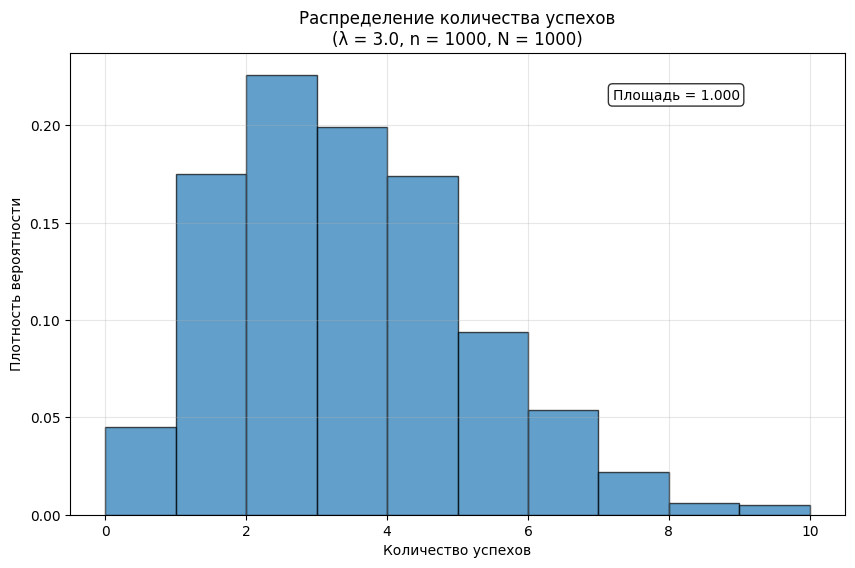

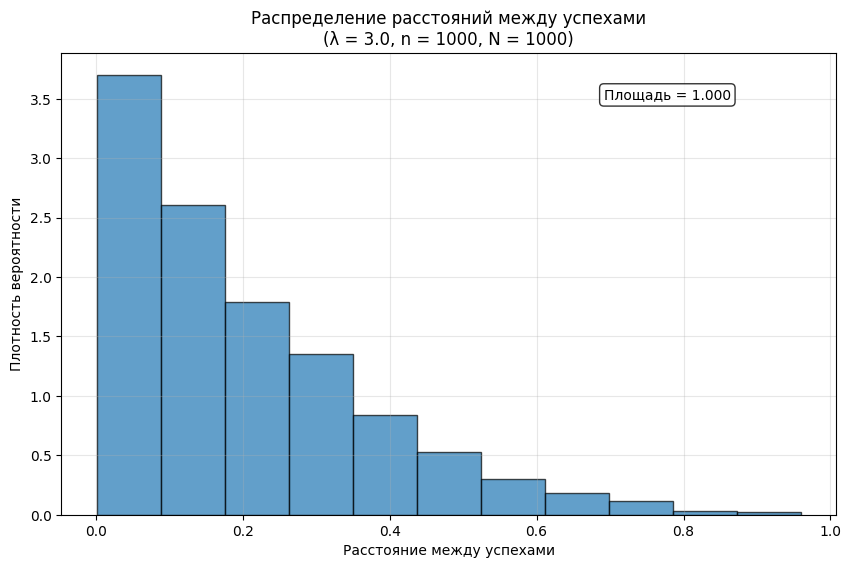

In [ ]:
def bernoulli_to_poisson(lambd, n, N):
    """
    Моделирует схему Бернулли на отрезке [0,1] и собирает статистик
    """
    p = min(lambd / n, 1)

    success_counts = []
    all_distances = []

    subintervals = []
    for i in range(n):
        start = i / n
        end = (i + 1) / n
        subintervals.append([start, end])

    for _ in range(N):
        # Для каждого подотрезка проводим испытание Бернулли
        successes = []
        for i, interval in enumerate(subintervals):
            if np.random.rand() < p:
                successes.append(i)

        success_counts.append(len(successes))

        if len(successes) > 1:
            # Вычисляем середины успешных подотрезков
            mid_points = []
            for idx in successes:
                start, end = subintervals[idx] #там пара так что значения разные
                mid = (start + end) / 2
                mid_points.append(mid)

            distances = np.diff(
                mid_points
            )  # np.diff() вычисляет разности между соседними элементами массива.
            all_distances.extend(
                distances
            )  # extend() добавляет все элементы из одного списка в другой:

    return np.array(success_counts), np.array(all_distances)


def plot_histogram(data, title, xlabel):
    """
    Строит гистограмму по правилам из задания
    """
    if len(data) == 0:
        print(f"Нет данных для построения гистограммы: {title}")
        return

    # количество столбцов по правилу Стёрджеса
    n_points = len(data)
    m = 1 + int(math.log2(n_points))

    #разбиваем отрезок [min, max] на m равных отрезков
    data_min = np.min(data)
    data_max = np.max(data)
    delta = (data_max - data_min) / m

    bins = np.linspace(data_min, data_max, m + 1)
    counts, bin_edges = np.histogram(data, bins=bins)

    # вычисляем высоты столбцов
    # h = (k/n) / Δ, = k/n * Δ где k - количество точек в отрезке
    heights = counts / (n_points * delta)

    plt.figure(figsize=(10, 6))
    plt.bar(
        bin_edges[:-1], heights, width=delta, alpha=0.7, edgecolor="black", align="edge"
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Плотность вероятности")
    plt.grid(True, alpha=0.3)

    # Проверяем, что площадь равна 1
    area = np.sum(heights * delta)
    plt.text(
        0.7,
        0.9,
        f"Площадь = {area:.3f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    plt.show()

lambd = 3.0  
n = 1000  
N = 1000 

print(f"Вероятность успеха p = {min(lambd/n, 1):.6f}")

success_counts, distances = bernoulli_to_poisson(lambd, n, N)

print(f"Количество успехов: {len(success_counts)} значений")
print(f"Среднее количество успехов: {np.mean(success_counts):.3f} (ожидаемое: {lambd})")
print(f"Расстояния между успехами: {len(distances)} значений")
if len(distances) > 0:
    print(f"Среднее расстояние: {np.mean(distances):.5f} (ожидаемое: {1/lambd:.5f})")

plot_histogram(
    success_counts,
    f"Распределение количества успехов\n(λ = {lambd}, n = {n}, N = {N})",
    "Количество успехов",
)

if len(distances) > 0:
    plot_histogram(
        distances,
        f"Распределение расстояний между успехами\n(λ = {lambd}, n = {n}, N = {N})",
        "Расстояние между успехами",
    )
else:
    print("Нет данных о расстояниях для построения гистограммы")


Параметры: λ = 3.0, N = 1000
Получено расстояний: 1974
Среднее расстояние: 0.20626 (ожидаемое: 0.33333)


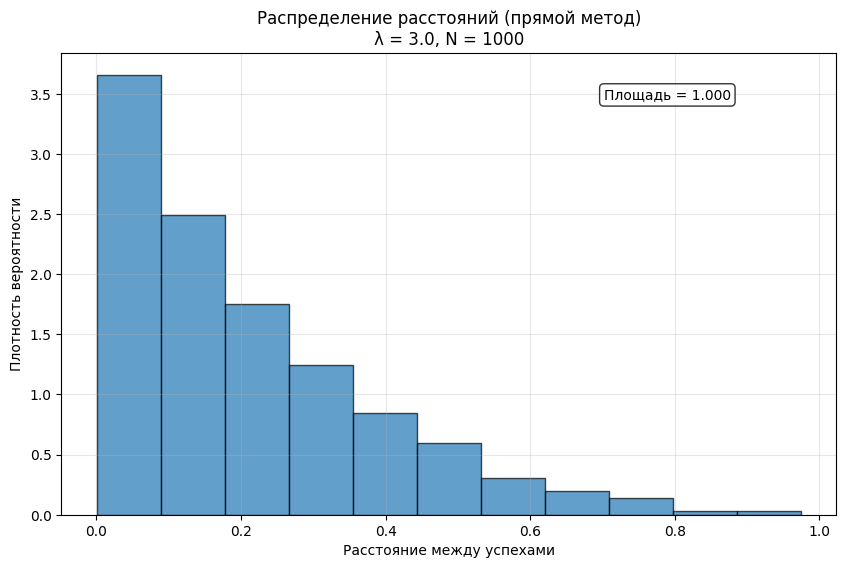

In [14]:
def poisson_process_direct(lambd, N):
    all_distances = []

    for _ in range(N):
        #генерируем случайную величину X согласно распределению Пуассона
        k = np.random.poisson(lambd)

        # выбираем X точек, равномерно распределённых на [0, 1]
        if k > 0:
            points = np.random.uniform(0, 1, k)
            points_sorted = np.sort(points)

            # Вычисляем расстояния между соседними точками
            if k > 1:
                distances = np.diff(points_sorted)
                all_distances.extend(distances)

    return np.array(all_distances)

lambd = 3.0
N = 1000

distances_direct = poisson_process_direct(lambd, N)

print(f"Параметры: λ = {lambd}, N = {N}")
print(f"Получено расстояний: {len(distances_direct)}")
if len(distances_direct) > 0:
    print(
        f"Среднее расстояние: {np.mean(distances_direct):.5f} (ожидаемое: {1/lambd:.5f})"
    )

if len(distances_direct) > 0:
    plot_histogram(
        distances_direct,
        f"Распределение расстояний (прямой метод)\nλ = {lambd}, N = {N}",
        "Расстояние между успехами",
    )
else:
    print("Нет данных о расстояниях для построения гистограммы")

1. Начинаем с времени t = 0
2. Пока не вышли за границу отрезка [0, 1]:
   а) Генерируем случайное расстояние d ~ Exp(λ)
   б) Новое время = текущее время + d
   в) Если новое время ≤ 1:
        - Записываем успех в этой точке
        - Обновляем текущее время
        - Переходим к шагу 2
   г) Если новое время > 1:
        - Завершаем процесс для этого запуска
3. Повторяем N раз

ИСПРАВЛЕННЫЙ метод показательных расстояний
Среднее количество успехов: 3.049 (ожидаемое: 3.0)
Среднее расстояние: 0.20058 (ожидаемое: 0.33333)
Параметры: λ = 3.0, N = 1000
Получено успехов: 1000 итераций
Среднее количество успехов: 2.923 (ожидаемое: 3.0)
Получено расстояний: 1982
Среднее расстояние: 0.21117 (ожидаемое: 0.33333)


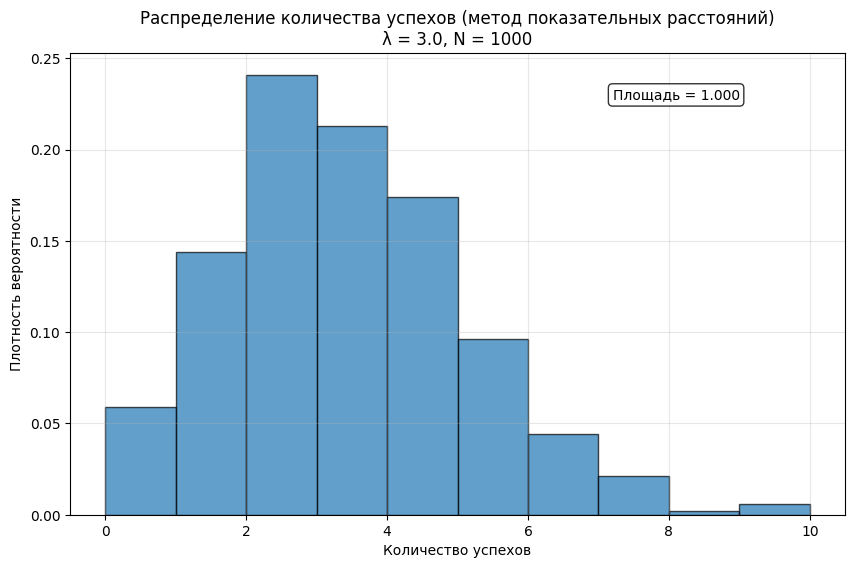

In [ ]:
def poisson_process_exponential_corrected(lambd, N):
    """моделирование Пуассоновского процесса через показательные расстояния
    """
    success_counts = []
    all_distances = []

    for _ in range(N):
        current_position = 0
        points = []
        distances = []

        while current_position <= 1:
            # scale = 1/λ
            distance = np.random.exponential(1 / lambd)
            new_position = current_position + distance

            if new_position <= 1:
                points.append(new_position)
                if len(points) > 1:
                    # Расстояние между последними двумя точками
                    dist_between = points[-1] - points[-2]
                    distances.append(dist_between)
                current_position = new_position
            else:
                break

        success_counts.append(len(points))
        all_distances.extend(distances)

    return np.array(success_counts), np.array(all_distances)


lambd = 3.0
N = 1000

success_counts_exp, distances_exp = poisson_process_exponential_corrected(lambd, N)

print(f"Параметры: λ = {lambd}, N = {N}")
print(f"Получено успехов: {len(success_counts_exp)} итераций")
print(
    f"Среднее количество успехов: {np.mean(success_counts_exp):.3f} (ожидаемое: {lambd})"
)
print(f"Получено расстояний: {len(distances_exp)}")
if len(distances_exp) > 0:
    print(
        f"Среднее расстояние: {np.mean(distances_exp):.5f} (ожидаемое: {1/lambd:.5f})"
    )

plot_histogram(
    success_counts_exp,
    f"Распределение количества успехов (метод показательных расстояний)\nλ = {lambd}, N = {N}",
    "Количество успехов",
)